# Experiment: Comparison of Different Regression Algorithms for Predictive Modeling

## House Price Prediction
### Aim

To compare the performance of different regression algorithms on a house price dataset and identify the most suitable algorithm for accurate house price prediction.

### Objectives

- Understand different regression algorithms.
- Apply multiple regression models to the same house price dataset.
- Evaluate models using suitable regression metrics.
- Compare model performance using cross-validation.
- Tune the best-performing model for improved prediction.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    GridSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    PolynomialFeatures,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load the house price dataset
df = pd.read_csv(r"C:\Users\SWARA\Downloads\TY\Sem 5\ML Lab\Dataset\house price\Housing.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
print("Statistical Summary:")
df.describe(include="all").T

Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
price,545.0,NaN,NaN,NaN,4766729.247706,1870439.615657,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,NaN,NaN,NaN,5150.541284,2170.141023,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,NaN,NaN,NaN,2.965138,0.738064,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,NaN,NaN,NaN,1.286239,0.50247,1.0,1.0,1.0,2.0,4.0
stories,545.0,NaN,NaN,NaN,1.805505,0.867492,1.0,1.0,2.0,2.0,4.0
mainroad,545,2,yes,468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
guestroom,545,2,no,448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
basement,545,2,no,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hotwaterheating,545,2,no,520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airconditioning,545,2,no,373,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


## Data Preprocessing

In [7]:
# Check missing values
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Missing Values:")
print(missing_values)

Missing Values:
Series([], dtype: int64)


In [8]:
# Check duplicate records
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [10]:
# Display unique values for categorical columns
categorical_columns = df.select_dtypes(include=["object", "category"]).columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].nunique(), "unique values")
    print(df[column].unique()[:10])


mainroad:
2 unique values
['yes' 'no']

guestroom:
2 unique values
['no' 'yes']

basement:
2 unique values
['no' 'yes']

hotwaterheating:
2 unique values
['no' 'yes']

airconditioning:
2 unique values
['yes' 'no']

prefarea:
2 unique values
['yes' 'no']

furnishingstatus:
3 unique values
['furnished' 'semi-furnished' 'unfurnished']


## Identify Target Variable

In [11]:
# Display all columns for target selection
for i, column in enumerate(df.columns):
    print(i, ":", column)

0 : price
1 : area
2 : bedrooms
3 : bathrooms
4 : stories
5 : mainroad
6 : guestroom
7 : basement
8 : hotwaterheating
9 : airconditioning
10 : parking
11 : prefarea
12 : furnishingstatus


In [12]:
# Automatically detect a common house-price target column
possible_targets = [
    "price",
    "Price",
    "PRICE",
    "house_price",
    "HousePrice",
    "SalePrice",
    "sale_price",
    "target",
    "Target"
]

target_column = None

for column in possible_targets:
    if column in df.columns:
        target_column = column
        break

if target_column is None:
    raise ValueError(
        "Target column was not automatically detected. "
        "Please set target_column manually."
    )

print("Target Variable:", target_column)

Target Variable: price


In [13]:
# Separate input features and target
X = df.drop(columns=[target_column])
y = df[target_column]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget variable:", target_column)

Feature shape: (545, 12)
Target shape: (545,)

Target variable: price


In [14]:
# Ensure target is numeric
if not pd.api.types.is_numeric_dtype(y):
    y = pd.to_numeric(y, errors="coerce")

# Remove rows where target is missing
valid_rows = y.notna()

X = X.loc[valid_rows].copy()
y = y.loc[valid_rows].copy()

print("Final feature shape:", X.shape)
print("Final target shape:", y.shape)

Final feature shape: (545, 12)
Final target shape: (545,)


## Exploratory Data Analysis

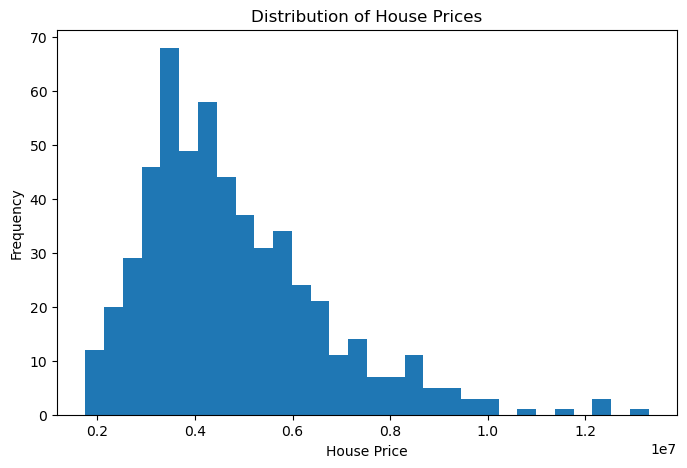

In [15]:
# Target variable distribution
plt.figure(figsize=(8, 5))

plt.hist(y, bins=30)

plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")

plt.show()

In [16]:
# Correlation of numerical features with target
numeric_df = df.select_dtypes(include=np.number)

if target_column in numeric_df.columns:
    correlation = numeric_df.corr()[target_column].sort_values(
        ascending=False
    )

    print("Correlation with Target:")
    print(correlation)

Correlation with Target:
price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64


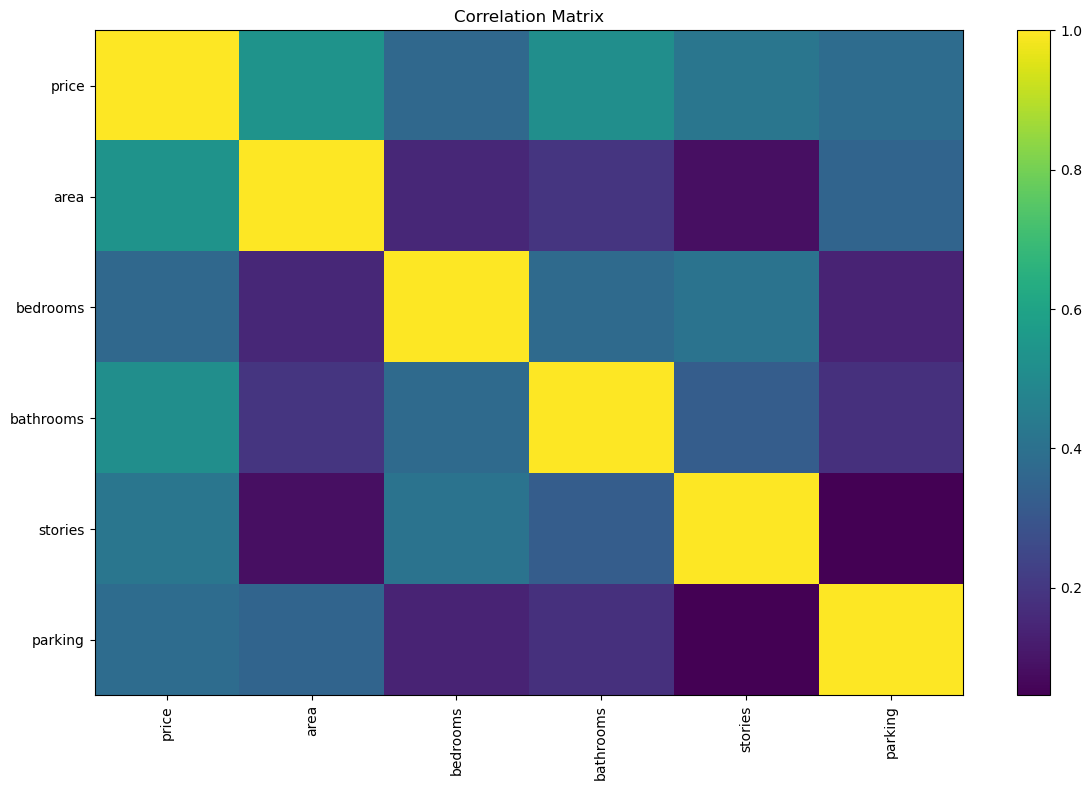

In [17]:
# Correlation heatmap
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))

plt.imshow(correlation_matrix, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

## Feature Identification

In [18]:
numeric_features = X.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

Categorical Features:
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [19]:
## Train-Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 436
Testing samples: 109


## Data Preprocessing Pipeline

In [21]:
# Preprocessing for numerical and categorical features

numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", __import__("sklearn").impute.SimpleImputer(strategy="median"))
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", __import__("sklearn").impute.SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor, numeric_features),
        ("cat", categorical_preprocessor, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## Model 1: Linear Regression

In [22]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


## Model 2: Polynomial Regression

In [23]:
# Polynomial regression is applied to numerical features.
# Categorical features are one-hot encoded separately.

poly_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        __import__("sklearn").impute.SimpleImputer(
                            strategy="median"
                        )
                    ),
                    (
                        "poly",
                        PolynomialFeatures(
                            degree=2,
                            include_bias=False
                        )
                    )
                ]
            ),
            numeric_features
        ),
        (
            "cat",
            categorical_preprocessor,
            categorical_features
        )
    ],
    remainder="drop"
)

polynomial_model = Pipeline(
    steps=[
        ("preprocessor", poly_preprocessor),
        ("scaler", StandardScaler(with_mean=False)),
        ("model", LinearRegression())
    ]
)

polynomial_model.fit(X_train, y_train)

polynomial_predictions = polynomial_model.predict(X_test)

print("Polynomial Regression trained successfully.")

Polynomial Regression trained successfully.


## Model 3: Decision Tree Regression

In [24]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                random_state=42
            )
        )
    ]
)

decision_tree_model.fit(X_train, y_train)

decision_tree_predictions = decision_tree_model.predict(X_test)

print("Decision Tree Regression trained successfully.")

Decision Tree Regression trained successfully.


## Model 4: Random Forest Regression

In [25]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_test)

print("Random Forest Regression trained successfully.")

Random Forest Regression trained successfully.


## Model 5: Support Vector Regression

In [26]:
svr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("scaler", StandardScaler(with_mean=False)),
        (
            "model",
            SVR(
                kernel="rbf"
            )
        )
    ]
)

svr_model.fit(X_train, y_train)

svr_predictions = svr_model.predict(X_test)

print("Support Vector Regression trained successfully.")

Support Vector Regression trained successfully.


## Model Evaluation

In [27]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return mae, mse, rmse, r2

In [28]:
predictions = {
    "Linear Regression": linear_predictions,
    "Polynomial Regression": polynomial_predictions,
    "Decision Tree": decision_tree_predictions,
    "Random Forest": random_forest_predictions,
    "SVR": svr_predictions
}

results = []

for model_name, prediction in predictions.items():
    mae, mse, rmse, r2 = evaluate_model(
        y_test,
        prediction
    )

    results.append({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.754319e+12,1.324507e+06,0.652924
1,Polynomial Regression,9.783144e+05,1.771055e+12,1.330810e+06,0.649613
2,Random Forest,1.025824e+06,1.971426e+12,1.404075e+06,0.609972
3,Decision Tree,1.234858e+06,2.888729e+12,1.699626e+06,0.428492
4,SVR,1.763890e+06,5.567938e+12,2.359648e+06,-0.101565


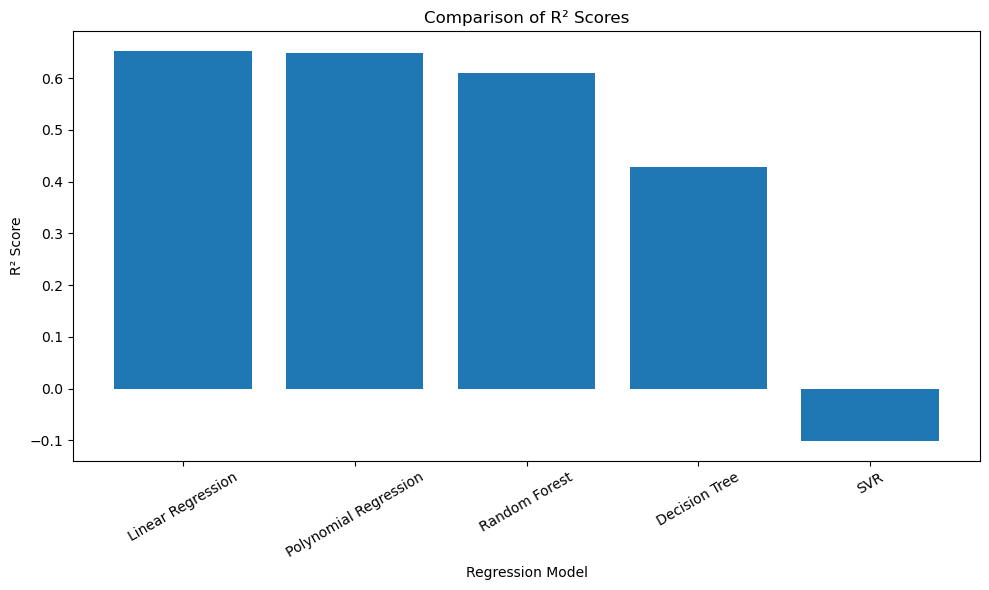

In [29]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["R2 Score"]
)

plt.xlabel("Regression Model")
plt.ylabel("R² Score")
plt.title("Comparison of R² Scores")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

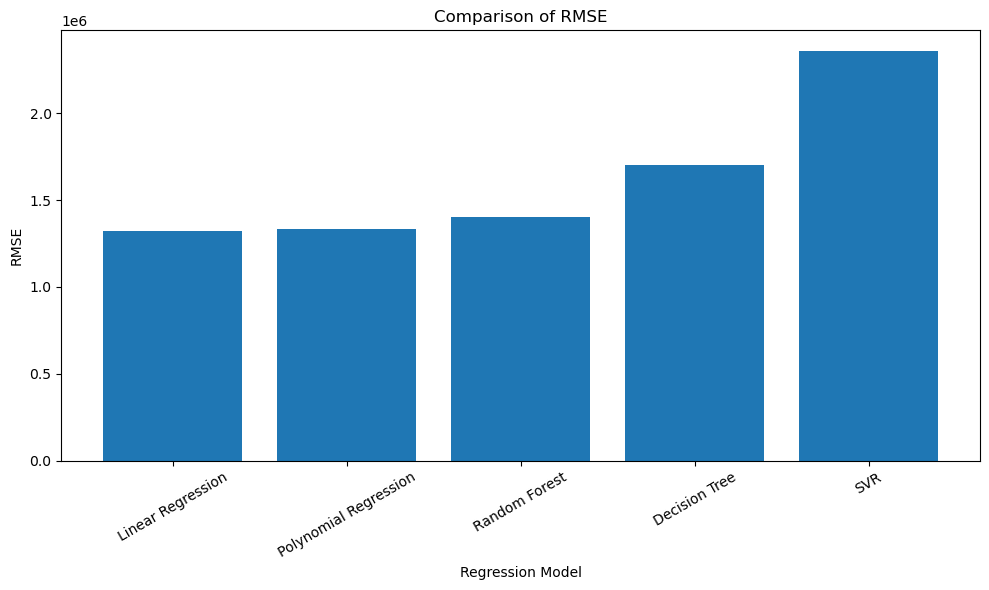

In [30]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.xlabel("Regression Model")
plt.ylabel("RMSE")
plt.title("Comparison of RMSE")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## Actual vs Predicted Prices

In [31]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model based on R² Score:", best_model_name)

Best Model based on R² Score: Linear Regression


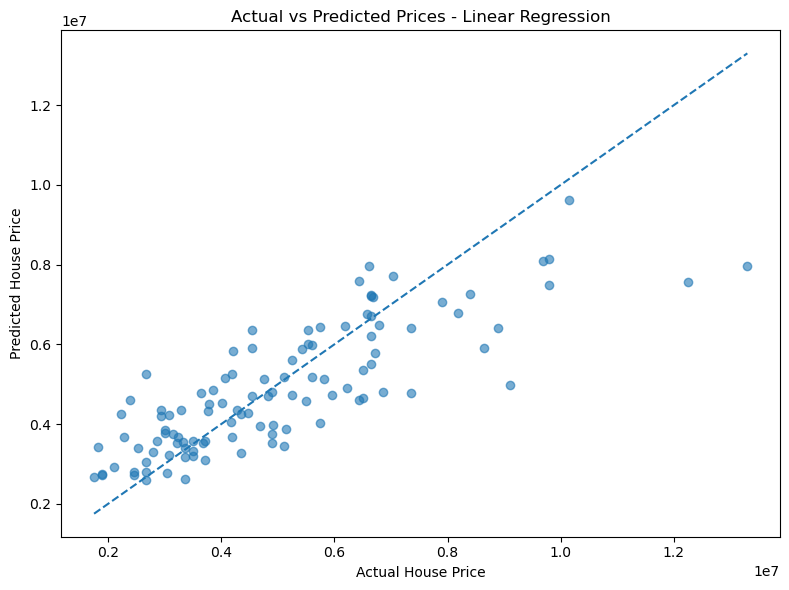

In [32]:
best_predictions = predictions[best_model_name]

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.6
)

minimum = min(y_test.min(), best_predictions.min())
maximum = max(y_test.max(), best_predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title(f"Actual vs Predicted Prices - {best_model_name}")

plt.tight_layout()
plt.show()

## Residual Analysis

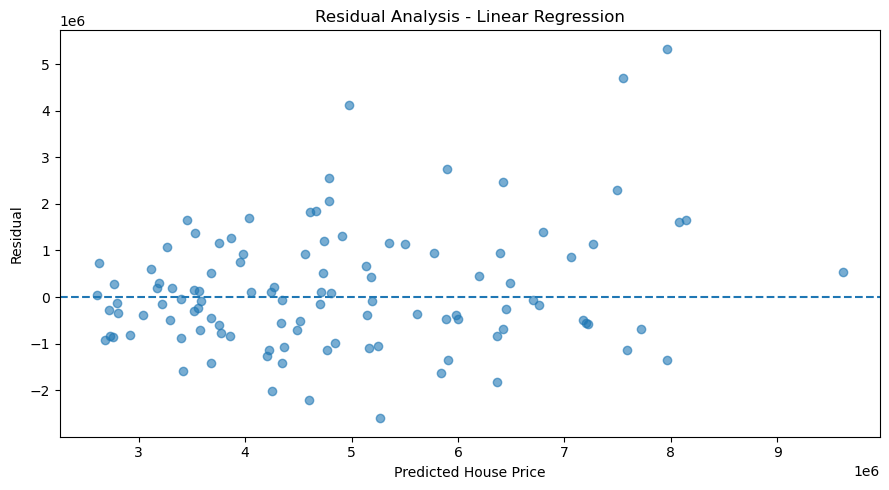

In [33]:
residuals = y_test - best_predictions

plt.figure(figsize=(9, 5))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted House Price")
plt.ylabel("Residual")
plt.title(f"Residual Analysis - {best_model_name}")

plt.tight_layout()
plt.show()

## K-Fold Cross-Validation

In [34]:
models_for_cv = {
    "Linear Regression": linear_model,
    "Polynomial Regression": polynomial_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "SVR": svr_model
}

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for model_name, model in models_for_cv.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="r2",
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "Mean CV R2": scores.mean(),
        "Std CV R2": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="Mean CV R2",
    ascending=False
).reset_index(drop=True)

cv_results_df

,Model,Mean CV R2,Std CV R2
0,Linear Regression,0.632448,0.073655
1,Polynomial Regression,0.631698,0.054578
2,Random Forest,0.615724,0.063612
3,Decision Tree,0.190848,0.278134
4,SVR,-0.059762,0.048744


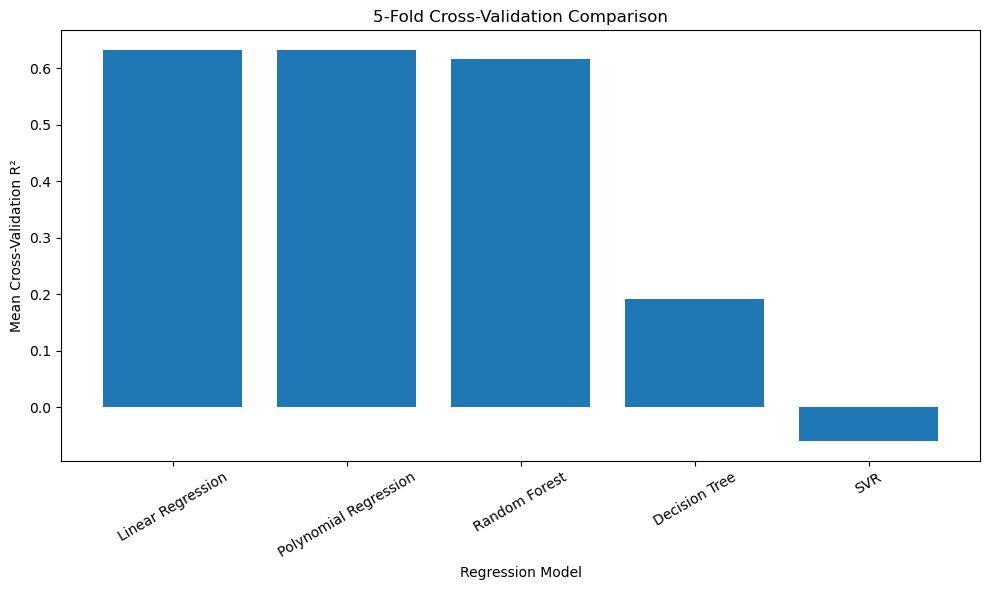

In [35]:
plt.figure(figsize=(10, 6))

plt.bar(
    cv_results_df["Model"],
    cv_results_df["Mean CV R2"]
)

plt.xlabel("Regression Model")
plt.ylabel("Mean Cross-Validation R²")
plt.title("5-Fold Cross-Validation Comparison")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## Hyperparameter Tuning

In [36]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation R²:")
print(grid_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best Cross-Validation R²:
0.6156555814303131


## Tuned Random Forest Evaluation

In [37]:
tuned_rf_predictions = grid_search.predict(X_test)

tuned_rf_mae = mean_absolute_error(
    y_test,
    tuned_rf_predictions
)

tuned_rf_mse = mean_squared_error(
    y_test,
    tuned_rf_predictions
)

tuned_rf_rmse = np.sqrt(
    tuned_rf_mse
)

tuned_rf_r2 = r2_score(
    y_test,
    tuned_rf_predictions
)

tuned_rf_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ],
    "Tuned Random Forest": [
        tuned_rf_mae,
        tuned_rf_mse,
        tuned_rf_rmse,
        tuned_rf_r2
    ]
})

tuned_rf_results

,Metric,Tuned Random Forest
0,MAE,1.053299e+06
1,MSE,2.047033e+12
2,RMSE,1.430746e+06
3,R2 Score,5.950134e-01


## Before and After Hyperparameter Tuning

In [38]:
original_rf_result = results_df[
    results_df["Model"] == "Random Forest"
].iloc[0]

tuning_comparison = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ],
    "Original Random Forest": [
        original_rf_result["MAE"],
        original_rf_result["MSE"],
        original_rf_result["RMSE"],
        original_rf_result["R2 Score"]
    ],
    "Tuned Random Forest": [
        tuned_rf_mae,
        tuned_rf_mse,
        tuned_rf_rmse,
        tuned_rf_r2
    ]
})

tuning_comparison

,Metric,Original Random Forest,Tuned Random Forest
0,MAE,1.025824e+06,1.053299e+06
1,MSE,1.971426e+12,2.047033e+12
2,RMSE,1.404075e+06,1.430746e+06
3,R2 Score,6.099716e-01,5.950134e-01


## Final Model Comparison

In [39]:
final_results = results_df.copy()

tuned_rf_row = pd.DataFrame([{
    "Model": "Tuned Random Forest",
    "MAE": tuned_rf_mae,
    "MSE": tuned_rf_mse,
    "RMSE": tuned_rf_rmse,
    "R2 Score": tuned_rf_r2
}])

final_results = pd.concat(
    [
        final_results,
        tuned_rf_row
    ],
    ignore_index=True
)

final_results = final_results.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

final_results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.754319e+12,1.324507e+06,0.652924
1,Polynomial Regression,9.783144e+05,1.771055e+12,1.330810e+06,0.649613
2,Random Forest,1.025824e+06,1.971426e+12,1.404075e+06,0.609972
3,Tuned Random Forest,1.053299e+06,2.047033e+12,1.430746e+06,0.595013
4,Decision Tree,1.234858e+06,2.888729e+12,1.699626e+06,0.428492
5,SVR,1.763890e+06,5.567938e+12,2.359648e+06,-0.101565


In [40]:
print("Final Ranking of Models:\n")

for rank, row in final_results.iterrows():
    print(
        f"{rank + 1}. {row['Model']} "
        f"| R² = {row['R2 Score']:.4f} "
        f"| RMSE = {row['RMSE']:.4f}"
    )

Final Ranking of Models:

1. Linear Regression | R² = 0.6529 | RMSE = 1324506.9601
2. Polynomial Regression | R² = 0.6496 | RMSE = 1330810.0746
3. Random Forest | R² = 0.6100 | RMSE = 1404074.8184
4. Tuned Random Forest | R² = 0.5950 | RMSE = 1430745.7272
5. Decision Tree | R² = 0.4285 | RMSE = 1699626.1441
6. SVR | R² = -0.1016 | RMSE = 2359647.9053


In [41]:
final_best_model_name = final_results.iloc[0]["Model"]

if final_best_model_name == "Tuned Random Forest":
    final_model = grid_search
else:
    final_model = models_for_cv[final_best_model_name]

sample_input = X_test.iloc[[0]]

actual_price = y_test.iloc[0]
predicted_price = final_model.predict(sample_input)[0]

print("Best Model:", final_best_model_name)
print("Actual House Price:", actual_price)
print("Predicted House Price:", predicted_price)

Best Model: Linear Regression
Actual House Price: 4060000
Predicted House Price: 5164653.900339675


## Conclusion
The performance of Linear Regression, Polynomial Regression, Decision Tree Regression, Random Forest Regression, and Support Vector Regression was compared for house price prediction.

The models were evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. Lower MAE, MSE, and RMSE indicate lower prediction error, while a higher R² Score indicates better explanatory and predictive performance.

In addition to the basic train-test evaluation, 5-fold cross-validation was performed to obtain a more reliable estimate of model generalization. Hyperparameter tuning was also applied to the Random Forest model to determine whether its predictive performance could be improved.

The model with the highest R² Score and lowest prediction error can be considered the most suitable model for the given house price prediction problem.

In [42]:
print("Best Performing Model:", final_results.iloc[0]["Model"])
print("Best R² Score:", round(final_results.iloc[0]["R2 Score"], 4))
print("Best RMSE:", round(final_results.iloc[0]["RMSE"], 4))
print("Best MAE:", round(final_results.iloc[0]["MAE"], 4))

Best Performing Model: Linear Regression
Best R² Score: 0.6529
Best RMSE: 1324506.9601
Best MAE: 970043.4039
